[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_2_Resampling.ipynb)

# 11.2: Resampling: Changing Time Resolution

In notebook 11.1 you plotted two years of daily bike rental counts. The seasonal shape was visible, but the line was noisy: individual days shot up or dropped down for reasons unrelated to the overall trend, and the chart was hard to read at a glance.

The fix is to change the time resolution. Instead of asking "how many rentals on this specific day?" you can ask "how many rentals this week?" or "what was the daily average this month?" That is what **resampling** does: it groups the rows by a time period and reduces each group to a single summary value, exactly like `groupby().agg()` except that the grouping key is time itself.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
keep = ["dteday", "season", "yr", "mnth", "holiday", "weekday",
        "workingday", "weathersit", "temp", "casual", "registered", "cnt"]
df = pd.read_csv(url, usecols=keep, parse_dates=["dteday"],
                 index_col="dteday").sort_index()
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,casual,registered,cnt
dteday,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,2,0.344167,331,654,985
2011-01-02,1,0,1,0,0,0,2,0.363478,131,670,801
2011-01-03,1,0,1,0,1,1,1,0.196364,120,1229,1349
2011-01-04,1,0,1,0,2,1,1,0.200000,108,1454,1562
2011-01-05,1,0,1,0,3,1,1,0.226957,82,1518,1600


## Rolling up to weekly totals

The daily plot in notebook 11.1 was noisy because weekdays and weekends differ, some days spike or drop for reasons like weather, and short-term fluctuations obscure the trend. Grouping by week smooths all of that out while still showing how ridership changed across the two years.

Weekly rows: 106
dteday
2011-01-02    1786
2011-01-09    9408
2011-01-16    9025
2011-01-23    8770
2011-01-30    7699
Freq: W-SUN, Name: cnt, dtype: int64


<Axes: title={'center': 'Weekly total rentals'}, xlabel='dteday', ylabel='Rentals'>

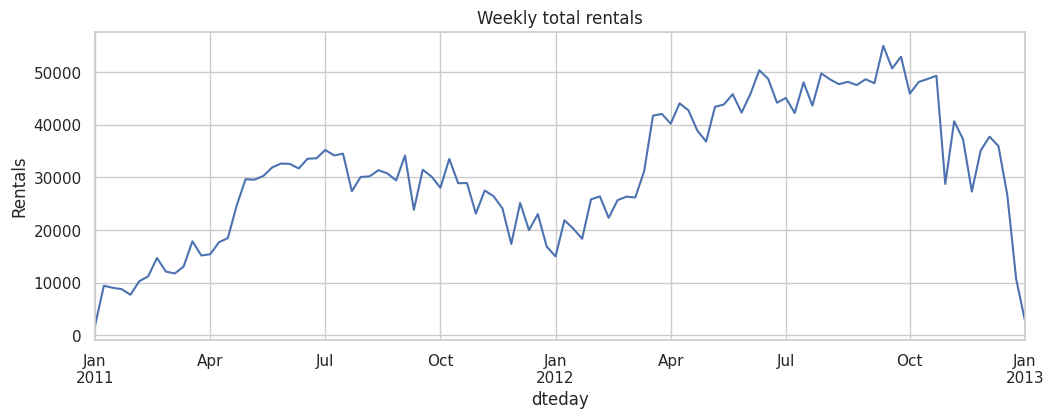

In [2]:
weekly = df["cnt"].resample("W").sum()
print("Weekly rows:", len(weekly))
print(weekly.head())

weekly.plot(figsize=(12, 4), title="Weekly total rentals", ylabel="Rentals")

`resample("W")` groups the daily rows into seven-day bins. `.sum()` totals the rentals in each bin. The 731 daily rows become 106 weekly rows. The line is smoother than the daily version, and the seasonal pattern stands out clearly: summer peaks are roughly double the winter troughs.

## Choosing between sum and mean

Resampling always requires an aggregation function. The right choice depends on what the column represents.

`cnt` is a count of rentals on a single day. To answer "how many rentals happened this month?", the correct aggregation is `sum`: add up all the daily counts. To answer "on a typical day this month, how many rentals were there?", the correct aggregation is `mean`: average the daily counts.

Neither is universally right. The question decides.

In [3]:
monthly_sum  = df["cnt"].resample("ME").sum()
monthly_mean = df["cnt"].resample("ME").mean()

print("Monthly sum (Jan 2011):", monthly_sum.iloc[0])
print("Monthly mean (Jan 2011):", monthly_mean.iloc[0].round(1))

Monthly sum (Jan 2011): 38189
Monthly mean (Jan 2011): 1231.9


In January 2011 there were 38,189 total rentals and an average of about 1,232 rentals per day. Both numbers describe the same month from different angles. For the charts in this module, `mean` usually tells a cleaner story because it is not inflated by months that happen to have more days; `sum` is more useful when the total matters (revenue, trips, items shipped).

## Comparing resolutions

Plotting daily, weekly, and monthly on separate axes shows concretely what smoothing costs and what it gains.

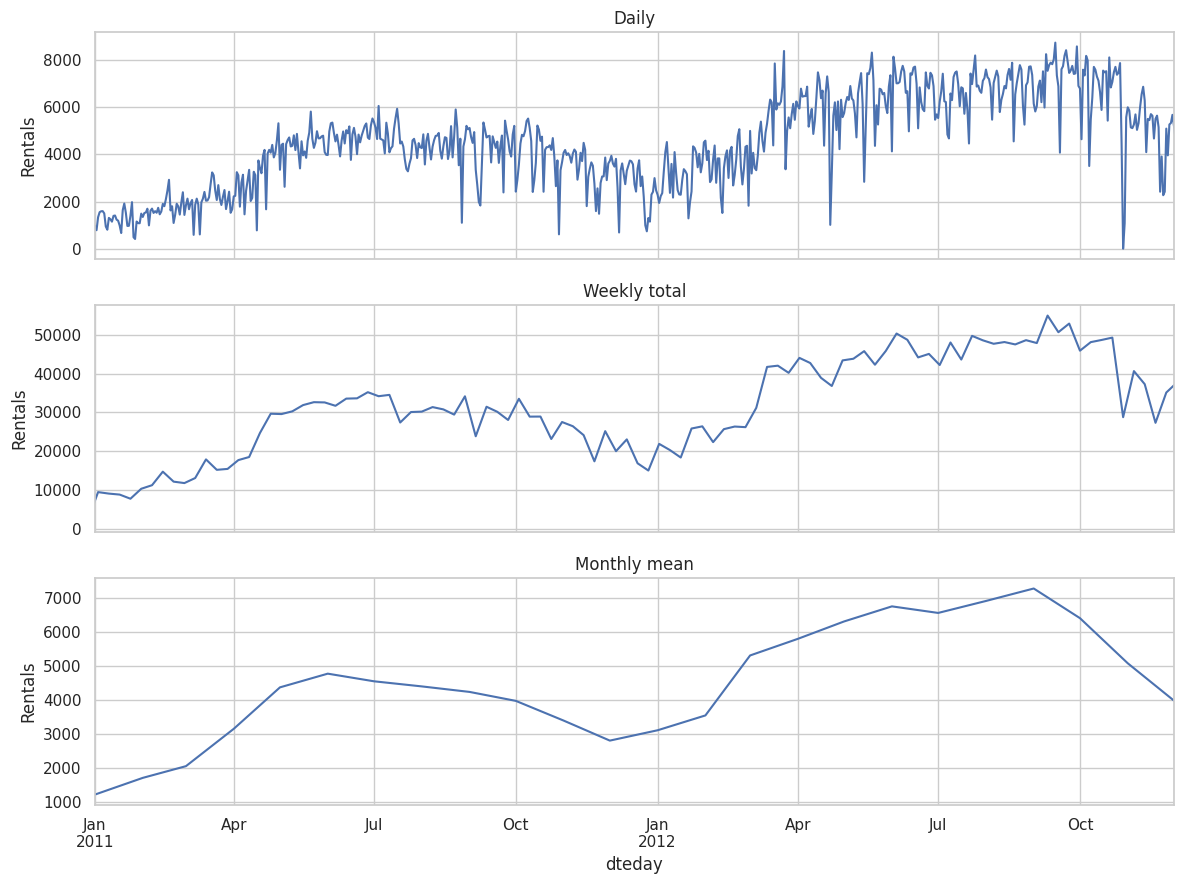

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

df["cnt"].plot(ax=axes[0], title="Daily")
df["cnt"].resample("W").sum().plot(ax=axes[1], title="Weekly total")
df["cnt"].resample("ME").mean().plot(ax=axes[2], title="Monthly mean")

for ax in axes:
    ax.set_ylabel("Rentals")
plt.tight_layout()

Moving from daily to weekly to monthly, the line becomes progressively smoother. Day-to-day variation (noise) shrinks, and the broad shape (trend and seasonality) becomes easier to read. The tradeoff is resolution: the monthly view loses information about which specific weeks were unusual. Choose the resolution that matches the question you are trying to answer.

## Frequency strings

`resample()` takes a frequency string that specifies how to group the data. The strings you will use most often are listed below. Note that in pandas 3.0, month-end and quarter-end use `"ME"` and `"QE"` rather than the older `"M"` and `"Q"`, which are deprecated.

In [5]:
freqs = {
    "W":  "week ending Sunday",
    "ME": "month end",
    "QE": "quarter end",
    "YE": "year end",
}

for key, label in freqs.items():
    n = len(df["cnt"].resample(key).sum())
    print(f'resample("{key}")  -> {n:4d} rows  ({label})')

resample("W")  ->  106 rows  (week ending Sunday)
resample("ME")  ->   24 rows  (month end)
resample("QE")  ->    8 rows  (quarter end)
resample("YE")  ->    2 rows  (year end)


731 daily rows resample to 106 weekly rows, 24 monthly rows, 8 quarterly rows, or 2 annual rows. Each step up in frequency trades granularity for smoothness. For this dataset, weekly and monthly are the most informative: weekly preserves enough day-to-day texture to see transitions between seasons, while monthly gives a clean summary of the full two-year arc.

## What's next

Resampling changes the number of rows. But what if you want to smooth the daily data without changing the number of rows, so you can overlay the smoothed version on top of the raw data? That is what rolling windows do. In notebook 11.3 you will learn `.rolling()`: how to compute a moving average that reveals the trend while keeping every day visible.